# Week1-3: Coding MCMC from scratch


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [2]:
data_path = '../data/'
df = pd.read_csv(data_path+'Cas3_dg.csv')



In [3]:
# for each pair of (mean(vr), dispersion(vr)), we define the following function to calculate the log(L) for all the stars in the dwarf galaxy Cas III
def log_Likelihood(mvr, dvr, vr_dg):
    
    logL = np.sum(np.log(1/(dvr * np.sqrt(2 * np.pi))) - ((vr_dg - mvr)**2) / (2 * dvr**2))

    return logL

# Now let's add velocity uncertainties

def log_Likelihood_uncertainty(mvr, dvr, vr_dg, vr_dg_err):

    sigma = np.sqrt(dvr**2 + vr_dg_err**2)

    logL = np.sum(np.log(1/(sigma * np.sqrt(2 * np.pi))) - ((vr_dg - mvr)**2) / (2 * sigma**2))

    return logL 

Text(0.5, 0, 'Radial Velocity (km/s)')

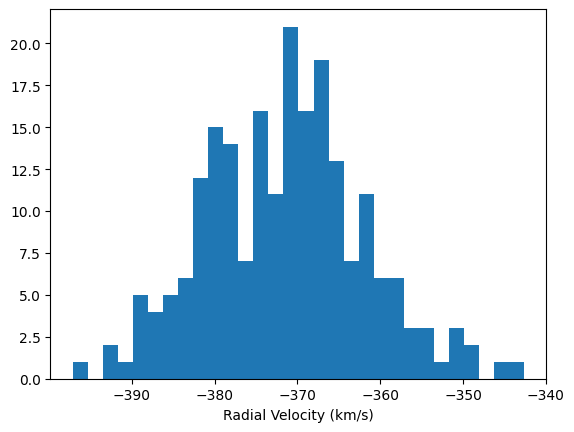

In [4]:
plt.figure()
plt.hist(df['vr'], bins=30);
plt.xlabel('Radial Velocity (km/s)')

In [5]:
# Estimate the starting values of mean and dispersion for the exploration
print (np.max(df['vr'])-np.min(df['vr']))
print (np.min(df['vr']))

54.44999999999999
-397.09


In [68]:
mvr0 = -400.0
dvr0 = 25.0
logL0 = log_Likelihood_uncertainty(mvr0, dvr0, df['vr'], df['e_vr'])
step_mvr = 2.0
step_dvr = 1.0
nsteps = 100000

mvr_steps = []
dvr_steps = []
index_steps = []

logL_steps = []

accepts = []

In [69]:
for i in range(nsteps):


    mvr_steps.append(mvr0)
    dvr_steps.append(dvr0)
    logL_steps.append(logL0)

    mvr1 = mvr0
    dvr1 = dvr0
    logL1 = logL0

    mvr1 = mvr1 + np.random.normal(0, step_mvr)
    dvr1 = dvr1 + np.random.normal(0, step_dvr)
    logL1 = log_Likelihood_uncertainty(mvr1, dvr1, df['vr'], df['e_vr'])
    index_steps.append(i)

    if logL1 > logL0:

        mvr0 = mvr1
        dvr0 = dvr1
        logL0 = logL1
        accepts.append(1)

    else:

        a = np.random.uniform(0, 1)
        if (logL1-logL0) > np.log(a):

            mvr0 = mvr1
            dvr0 = dvr1
            logL0 = logL1
            accepts.append(1)  

In [70]:
# calculate the acceptance rate
# Optimize the steps to get the acceptance rate around 20%
print(len(accepts)/nsteps)



0.22705


Text(0, 0.5, 'velocity disersion (km/s)')

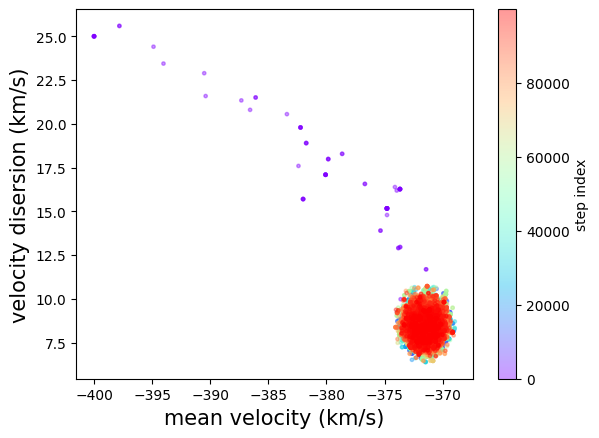

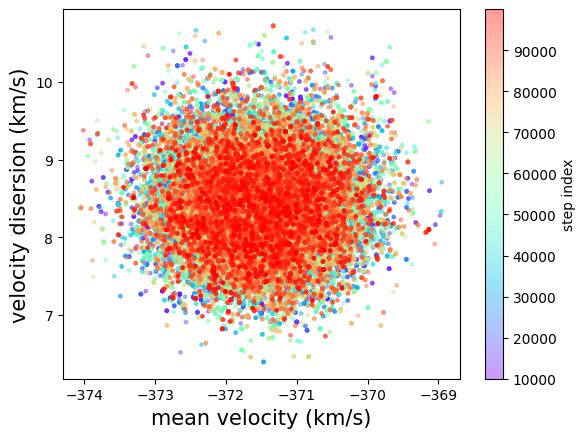

In [72]:
plt.figure()

im=plt.scatter(mvr_steps, dvr_steps, s=6, alpha=0.4, c=index_steps, cmap='rainbow')
plt.colorbar(im, label='step index')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity disersion (km/s)', fontsize=15)

plt.figure()

im=plt.scatter(mvr_steps[int(nsteps*0.1):], dvr_steps[int(nsteps*0.1):], 
               s=6, alpha=0.4, c=index_steps[int(nsteps*0.1):], cmap='rainbow')
plt.colorbar(im, label='step index')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity disersion (km/s)', fontsize=15)




Text(0.5, 0, 'mean velocity (km/s)')

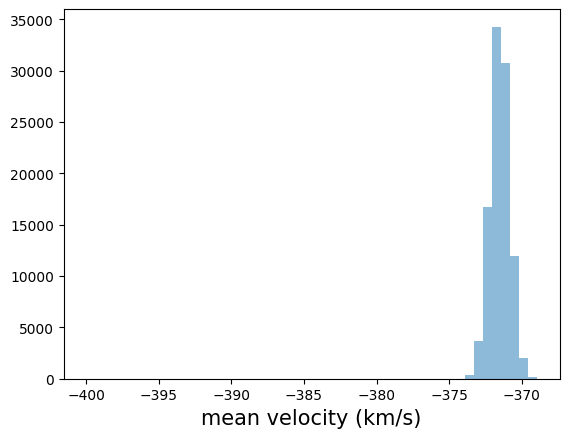

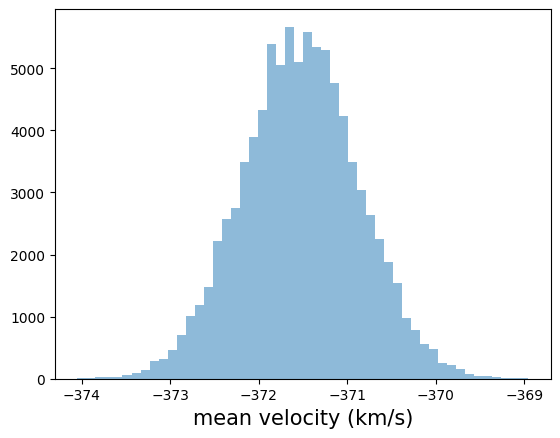

In [73]:
# The optimized step is around the disperson (sigma) of the PDF (FWHM=2.36*sigma)
# Then re-run MCMC usng the optimized steps!
plt.figure()
plt.hist(mvr_steps, bins=50, alpha=0.5);
plt.xlabel('mean velocity (km/s)', fontsize=15)

plt.figure()
plt.hist(mvr_steps[int(nsteps*0.1):], bins=50, alpha=0.5);
plt.xlabel('mean velocity (km/s)', fontsize=15)


Text(0.5, 0, 'velocity disersion (km/s)')

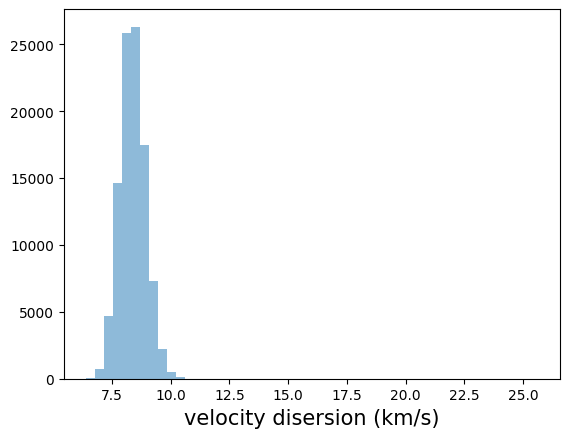

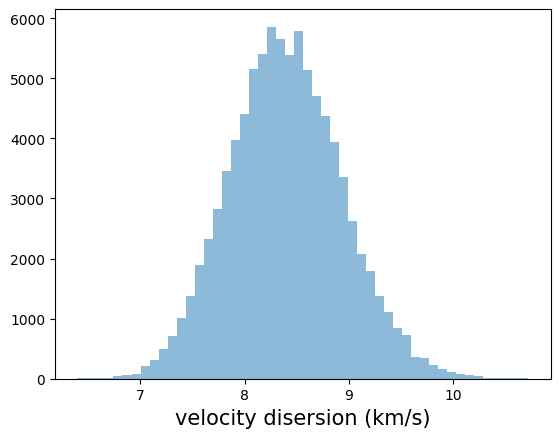

In [74]:
plt.figure()
plt.hist(dvr_steps, bins=50, alpha=0.5, label='dvr');
plt.xlabel('velocity disersion (km/s)', fontsize=15)

plt.figure()
plt.hist(dvr_steps[int(nsteps*0.1):], bins=50, alpha=0.5, label='dvr');
plt.xlabel('velocity disersion (km/s)', fontsize=15)


In [75]:
chain = np.vstack((mvr_steps, dvr_steps, logL_steps)).T[int(nsteps*0.1):]
chain.shape

(90000, 3)

In [13]:
np.savetxt(data_path+'chain_Cas3.txt', chain)


## Consider the foreground stars in the MW and run MCMC in 5D space

In [76]:
df0 = pd.read_csv(data_path+'Cas3_total.csv')

Text(0.5, 0, 'Radial Velocity (km/s)')

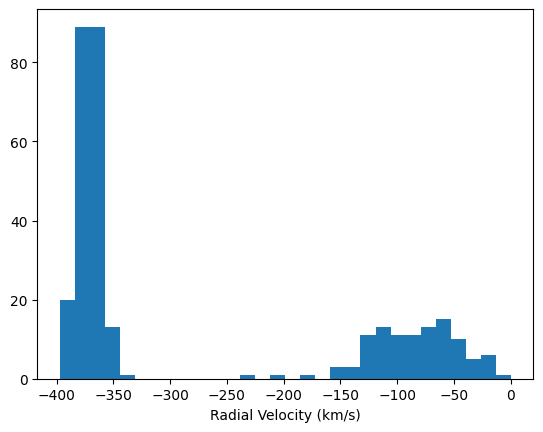

In [77]:
plt.figure()
plt.hist(df0['vr'], bins=30);
plt.xlabel('Radial Velocity (km/s)')

In [78]:
def log_Likelihood_uncertainty_2component(mvr1, dvr1, mvr2, dvr2, f, vr_dg, vr_dg_err):
    
    sigma1 = np.sqrt(dvr1**2 + vr_dg_err**2)
    sigma2 = np.sqrt(dvr2**2 + vr_dg_err**2)

    
    L1 = f/sigma1*np.exp(-0.5*((vr_dg - mvr1)/sigma1)**2.)
    L2 = (1-f)/sigma2*np.exp(-0.5*((vr_dg - mvr2)/sigma2)**2.)
    logL = np.sum(np.log(L1 + L2))


    return logL

In [113]:
mvr10 = -400.0
dvr10 = 10.0

mvr20 = -150.0
dvr20 = 50.0

f0=0.5


logL0 = log_Likelihood_uncertainty_2component(mvr10, dvr10, mvr20, dvr20, f0, df0['vr'], df0['e_vr'])

# refine the following steps based on the uncertainties of the results
step_mvr1 = .5
step_dvr1 = .5

step_mvr2 = 5.0
step_dvr2 = 2.0

step_f = 0.02

nsteps = 100000

mvr1_steps = []
dvr1_steps = []
mvr2_steps = []
dvr2_steps = []
f_steps = []
index_steps = []
logL_steps = []
accepts = []

In [114]:

for i in range(nsteps):
    
    mvr11 = mvr10
    dvr11 = dvr10
    mvr21 = mvr20
    dvr21 = dvr20
    f1 = f0
    logL1 = logL0

    mvr1_steps.append(mvr11)
    dvr1_steps.append(dvr11)
    mvr2_steps.append(mvr21)
    dvr2_steps.append(dvr21)
    f_steps.append(f1)
    logL_steps.append(logL1)
    index_steps.append(i)



    f1 = f1 + np.random.normal(0, step_f)
    dvr11 = dvr11 + np.random.normal(0, step_dvr1)   
    dvr21 = dvr21 + np.random.normal(0, step_dvr2)

    mvr11 = mvr11 + np.random.normal(0, step_mvr1)
    mvr21 = mvr21 + np.random.normal(0, step_mvr2)

    if (mvr11 < -200) & (mvr21 >= -200) & (dvr11 > 0) & (dvr21 > 0) & (f1 > 0) & (f1 < 1):
    
        # index_steps.append(i)
        logL1 = log_Likelihood_uncertainty_2component(mvr11, dvr11, mvr21, dvr21, f1, df0['vr'], df0['e_vr'])
        

        if logL1 > logL0:

            mvr10 = mvr11
            dvr10 = dvr11
            mvr20 = mvr21
            dvr20 = dvr21
            f0 = f1
            logL0 = logL1
            accepts.append(1)

        else:

            a = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(a):

                mvr10 = mvr11
                dvr10 = dvr11
                mvr20 = mvr21
                dvr20 = dvr21
                f0 = f1
                logL0 = logL1
                accepts.append(1)  
    
    



In [115]:
print (len(accepts)/nsteps)

0.36296


Text(0, 0.5, 'MW velocity disersion (km/s)')

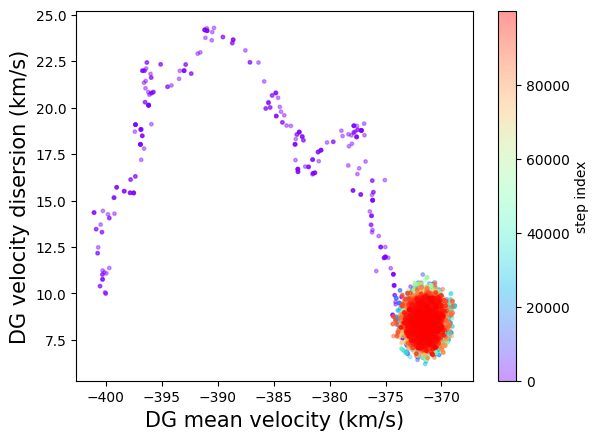

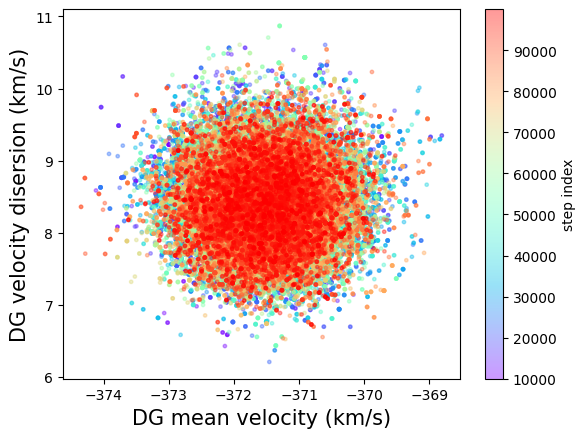

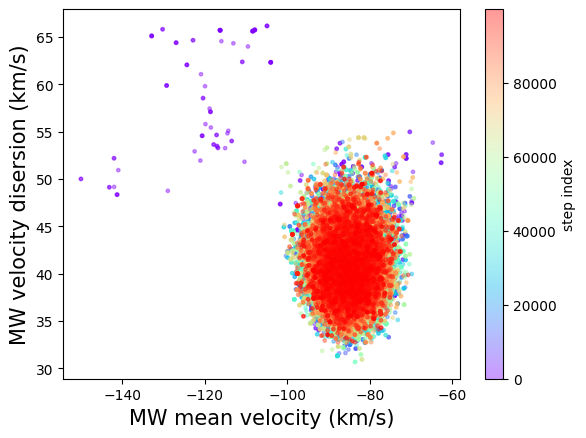

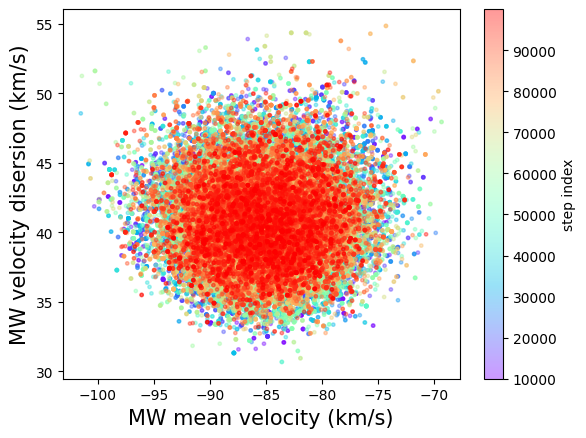

In [116]:
plt.figure()

im=plt.scatter(mvr1_steps, dvr1_steps, s=6, alpha=0.4, c=index_steps, cmap='rainbow')
plt.colorbar(im, label='step index')
plt.xlabel('DG mean velocity (km/s)', fontsize=15)
plt.ylabel('DG velocity disersion (km/s)', fontsize=15)

plt.figure()

im=plt.scatter(mvr1_steps[int(nsteps*0.1):], dvr1_steps[int(nsteps*0.1):], 
               s=6, alpha=0.4, c=index_steps[int(nsteps*0.1):], cmap='rainbow')
plt.colorbar(im, label='step index')

plt.xlabel('DG mean velocity (km/s)', fontsize=15)
plt.ylabel('DG velocity disersion (km/s)', fontsize=15)

plt.figure()

im=plt.scatter(mvr2_steps, dvr2_steps, s=6, alpha=0.4, c=index_steps, cmap='rainbow')
plt.colorbar(im, label='step index')
plt.xlabel('MW mean velocity (km/s)', fontsize=15)
plt.ylabel('MW velocity disersion (km/s)', fontsize=15)

plt.figure()

im=plt.scatter(mvr2_steps[int(nsteps*0.1):], dvr2_steps[int(nsteps*0.1):], 
               s=6, alpha=0.4, c=index_steps[int(nsteps*0.1):], cmap='rainbow')
plt.colorbar(im, label='step index')

plt.xlabel('MW mean velocity (km/s)', fontsize=15)
plt.ylabel('MW velocity disersion (km/s)', fontsize=15)


In [117]:
import corner
samples = np.column_stack([
    mvr1_steps,
    dvr1_steps,
    mvr2_steps,
    dvr2_steps,
    f_steps
])

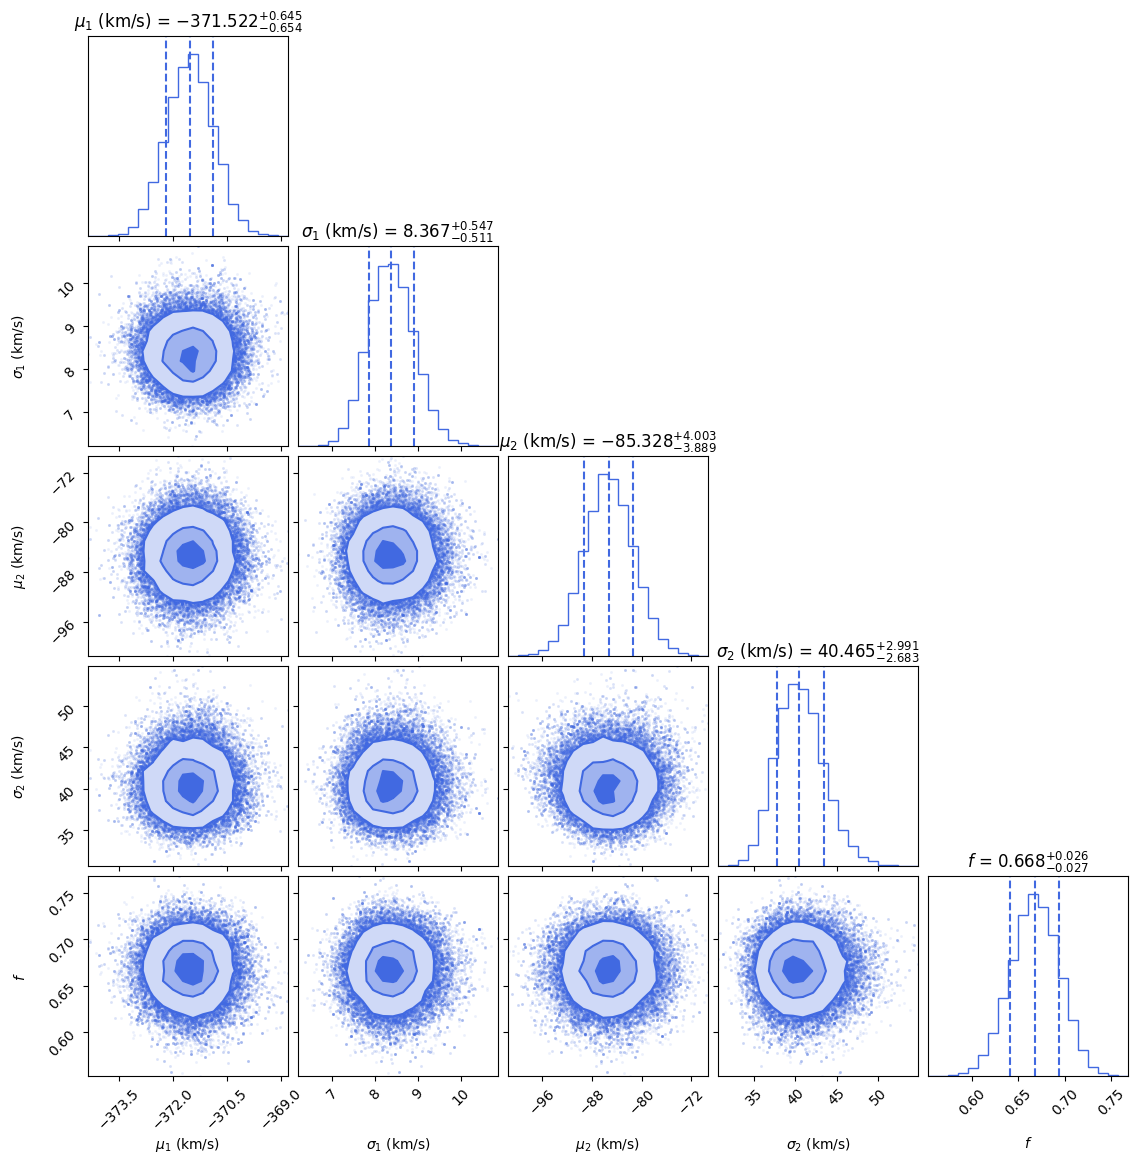

In [118]:
fig = corner.corner(
    samples[int(nsteps*0.1):],
    labels=[r"$\mu_1$ (km/s)", r"$\sigma_1$ (km/s)", r"$\mu_2$ (km/s)", r"$\sigma_2$ (km/s)", r"$f$"],
    # truths=[mvr1_true, dvr1_true, mvr2_true, dvr2_true, f_true],  # optional
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)